# Milestone 1: Data Collection & Preprocessing
**Project:** Intelligent Support Ticket Classification with RAG  
**Dataset:** MohammadOthman/mo-customer-support-tweets-945k  
**Environment:** Google Colab (GPU runtime)


## Mount Google Drive & install dependencies

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# All outputs persist in your Drive across sessions
import os
PROJECT_DIR = '/content/drive/MyDrive/support_rag_project'
for folder in ['data', 'outputs', 'outputs/milestone2', 'notebooks']:
    os.makedirs(f'{PROJECT_DIR}/{folder}', exist_ok=True)

!pip install -q datasets transformers sentence-transformers \
             pandas matplotlib seaborn wordcloud nltk tqdm


Mounted at /content/drive


## Imports

In [2]:
import os, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from tqdm.auto import tqdm

nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('stopwords',  quiet=True)

STOP_WORDS = set(stopwords.words('english'))

## Load dataset from Hugging Face

In [3]:
HF_PATH = 'hf://datasets/MohammadOthman/mo-customer-support-tweets-945k/preprocessed_data.json'

print('Loading full dataset (~945k rows)...')
df = pd.read_json(HF_PATH)

print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Loading full dataset (~945k rows)...
Shape   : (945278, 2)
Columns : ['input', 'output']
Memory  : 309.9 MB


,input,output
0,is the worst customer service,I would love the chance to review the account ...
1,y’all lie about your “great” connection. 5 bar...,H there! we would definitely like to work with...
2,Since I signed up with you....Since day 1,We understand your concerns and we would like ...


In [4]:
print('=== Data Quality Report ===')
print(f'Nulls:\n{df.isnull().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Empty inputs   : {(df["input"].str.strip() == "").sum()}')
print(f'Empty outputs  : {(df["output"].str.strip() == "").sum()}')

=== Data Quality Report ===
Nulls:
input     0
output    0
dtype: int64
Duplicate rows : 1838
Empty inputs   : 4971
Empty outputs  : 2097


## Drop duplicates & empty rows

In [5]:
print(f'Rows before cleaning : {len(df):,}')

df = df.drop_duplicates().reset_index(drop=True)
print(f'After drop duplicates: {len(df):,}')

df = df[df['input'].str.strip().str.len()  > 0]
df = df[df['output'].str.strip().str.len() > 0]
df = df.reset_index(drop=True)
print(f'After drop empties   : {len(df):,}')

df['input']  = df['input'].str.strip()
df['output'] = df['output'].str.strip()

# re-check
print(f'\nNulls remaining      : {df.isnull().sum().sum()}')
print(f'Duplicates remaining : {df.duplicated().sum()}')
print(f'\nFinal clean dataset  : {len(df):,} rows')

Rows before cleaning : 945,278
After drop duplicates: 943,440
After drop empties   : 936,793

Nulls remaining      : 0
Duplicates remaining : 0

Final clean dataset  : 936,793 rows


## Text cleaning function

In [6]:
def preprocess_text(text: str, remove_stopwords: bool = False) -> str:
    """
    Clean a single text string.
    remove_stopwords=False (default) preserves negations & intent words
    needed for accurate semantic search and RAG retrieval.
    Pass True only for EDA visualisations (word clouds, frequency charts).
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)        # URLs
    text = re.sub(r'<[^>]+>', '', text)                  # HTML tags
    text = re.sub(r"[^a-z0-9\s'.,!?]", ' ', text)       # special chars
    text = re.sub(r'\s+', ' ', text).strip()             # whitespace
    if remove_stopwords:
        tokens = word_tokenize(text)
        text = ' '.join([t for t in tokens if t not in STOP_WORDS and len(t) > 1])
    return text

# Quick test
sample = df['input'].iloc[1]
print(f'Original : {sample}')
print(f'Cleaned  : {preprocess_text(sample)}')

Original : y’all lie about your “great” connection. 5 bars LTE, still won’t load something. Smh.
Cleaned  : y all lie about your great connection. 5 bars lte, still won t load something. smh.


## Apply preprocessing to full corpus (GPU-accelerated via pandas)

In [7]:
tqdm.pandas(desc='Preprocessing')

print('Cleaning input column...')
df['input_clean']  = df['input'].progress_apply(preprocess_text)

print('Cleaning output column...')
df['output_clean'] = df['output'].progress_apply(preprocess_text)

# Drop rows where cleaning resulted in empty strings
before = len(df)
df = df[(df['input_clean'].str.len() > 2) & (df['output_clean'].str.len() > 2)].reset_index(drop=True)
print(f'\nDropped {before - len(df)} empty-after-clean rows.')
print(f'Final corpus: {len(df):,} rows')

Cleaning input column...


Preprocessing:   0%|          | 0/936793 [00:00<?, ?it/s]

Cleaning output column...


Preprocessing:   0%|          | 0/936793 [00:00<?, ?it/s]


Dropped 7602 empty-after-clean rows.
Final corpus: 929,191 rows


## Token-level stats

In [8]:
df['input_len']  = df['input_clean'].apply(lambda x: len(x.split()))
df['output_len'] = df['output_clean'].apply(lambda x: len(x.split()))
df['len_ratio']  = (df['output_len'] / (df['input_len'] + 1)).round(2)

print('Input length stats (words):')
print(df['input_len'].describe().round(1))
print('\nOutput length stats (words):')
print(df['output_len'].describe().round(1))

Input length stats (words):
count    929191.0
mean         18.8
std          10.3
min           1.0
25%          11.0
50%          18.0
75%          24.0
max         111.0
Name: input_len, dtype: float64

Output length stats (words):
count    929191.0
mean         19.1
std           8.3
min           1.0
25%          14.0
50%          19.0
75%          23.0
max          62.0
Name: output_len, dtype: float64


## Save cleaned corpus to Drive

In [9]:
save_path = f'{PROJECT_DIR}/outputs/cleaned_corpus.csv'
df[['input','output','input_clean','output_clean','input_len','output_len','len_ratio']].to_csv(save_path, index=False)
print(f'Saved -> {save_path}  ({os.path.getsize(save_path)/1e6:.1f} MB)')

Saved -> /content/drive/MyDrive/support_rag_project/outputs/cleaned_corpus.csv  (387.9 MB)


# EDA

## Text length distribution

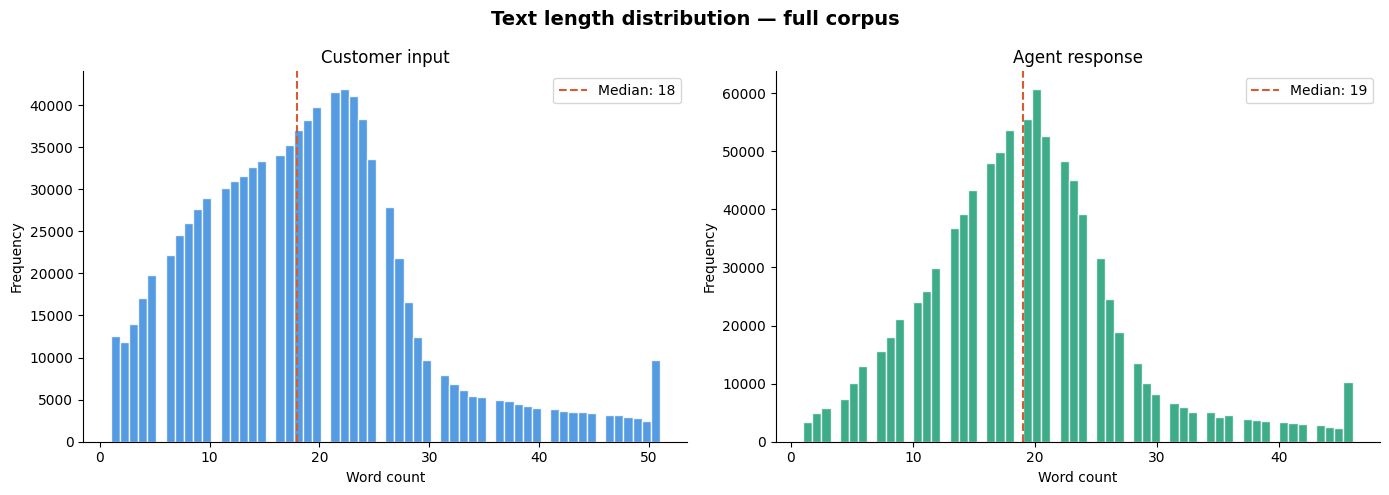

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Text length distribution — full corpus', fontsize=14, fontweight='bold')

for ax, col, label, color in zip(
    axes, ['input_len','output_len'],
    ['Customer input','Agent response'],
    ['#378ADD','#1D9E75']
):
    data = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(data, bins=60, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(data.median(), color='#D85A30', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.0f}')
    ax.set_title(label)
    ax.set_xlabel('Word count')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/outputs/length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Response/input length ratio

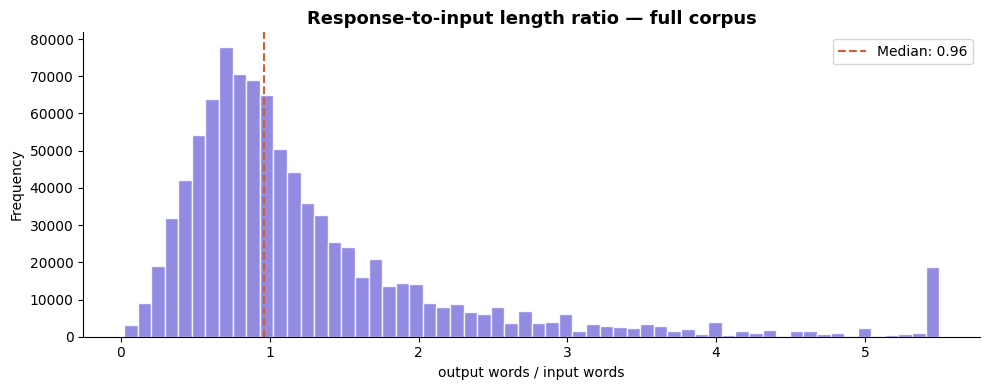

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ratio = df['len_ratio'].clip(upper=df['len_ratio'].quantile(0.98))
ax.hist(ratio, bins=60, color='#7F77DD', alpha=0.85, edgecolor='white')
ax.axvline(ratio.median(), color='#D85A30', linestyle='--', linewidth=1.5,
           label=f'Median: {ratio.median():.2f}')
ax.set_title('Response-to-input length ratio — full corpus', fontsize=13, fontweight='bold')
ax.set_xlabel('output words / input words')
ax.set_ylabel('Frequency')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/outputs/length_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## Top 30 words
> `remove_stopwords=True` here because we want topic keywords for visualisation, not sentence structure.


Computing top words for inputs (stopwords removed for visualisation)...


Tokenising:   0%|          | 0/100000 [00:00<?, ?it/s]

Computing top words for outputs...


Tokenising:   0%|          | 0/100000 [00:00<?, ?it/s]

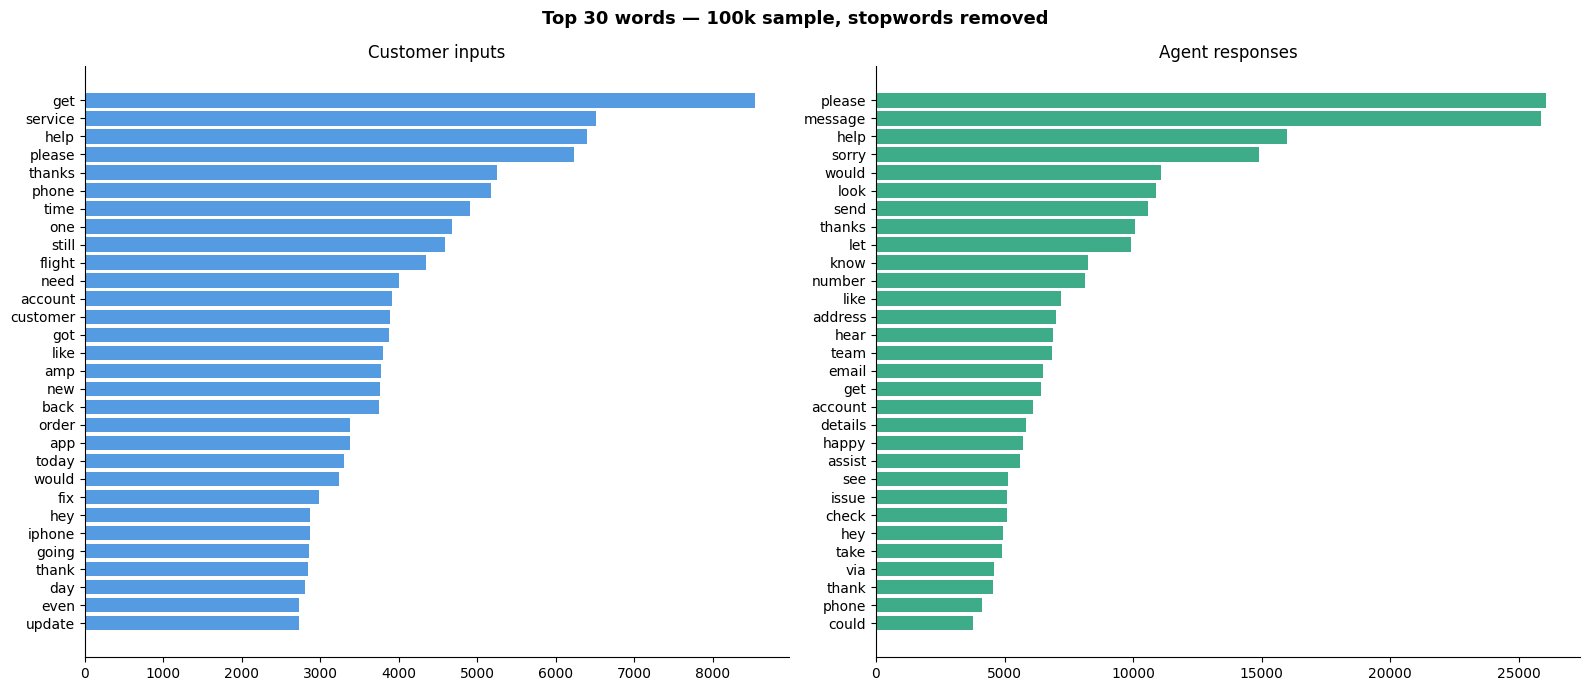

In [12]:
def get_top_words(series, n=30):
    all_words = []
    # Use a 100k sample for speed — still statistically representative at 945k
    for text in tqdm(series.sample(min(100_000, len(series)), random_state=42), desc='Tokenising'):
        tokens = word_tokenize(str(text))
        tokens = [t for t in tokens if t not in STOP_WORDS and t.isalpha() and len(t) > 2]
        all_words.extend(tokens)
    return Counter(all_words).most_common(n)

# Clean with stopwords removed — only for EDA
print('Computing top words for inputs (stopwords removed for visualisation)...')
top_input  = get_top_words(df['input_clean'])
print('Computing top words for outputs...')
top_output = get_top_words(df['output_clean'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 30 words — 100k sample, stopwords removed', fontsize=13, fontweight='bold')

for ax, top, label, color in zip(
    axes, [top_input, top_output],
    ['Customer inputs','Agent responses'],
    ['#378ADD','#1D9E75']
):
    words, counts = zip(*top)
    y = range(len(words)-1, -1, -1)
    ax.barh(list(y), counts, color=color, alpha=0.85)
    ax.set_yticks(list(y))
    ax.set_yticklabels(words, fontsize=10)
    ax.set_title(label)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/outputs/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## Word clouds (stopwords removed for visualisation)

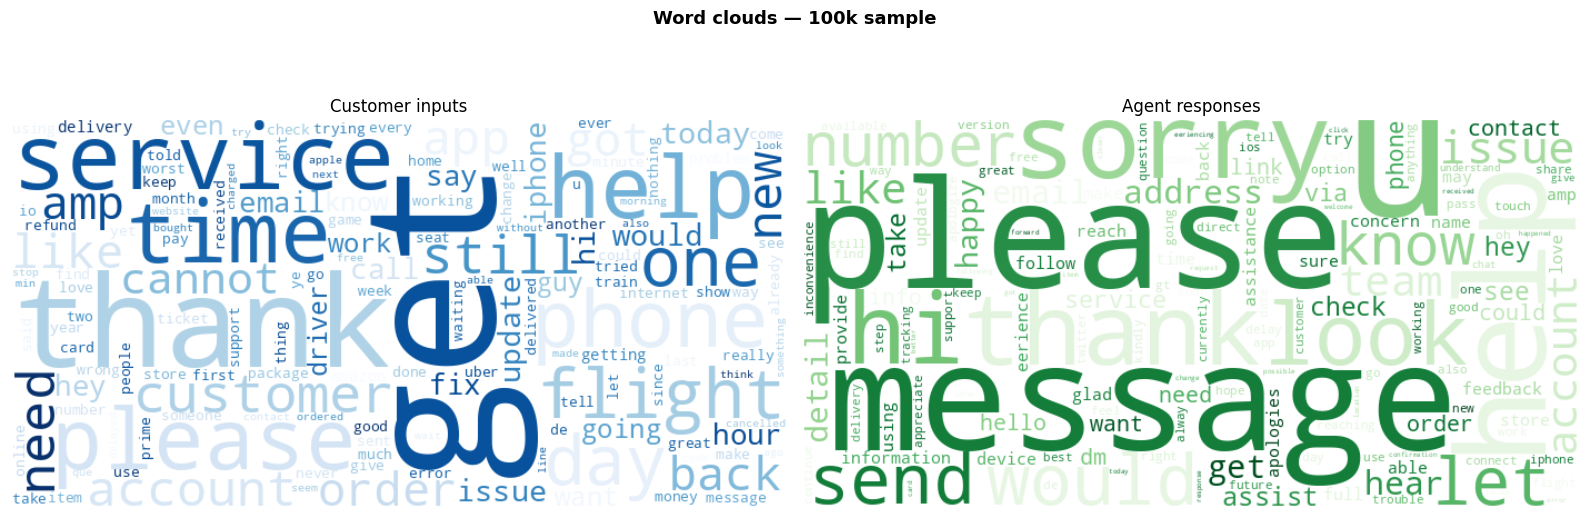

In [13]:
sample_text = df.sample(100_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word clouds — 100k sample', fontsize=13, fontweight='bold')

for ax, col, label, cmap in zip(
    axes, ['input_clean','output_clean'],
    ['Customer inputs','Agent responses'],
    ['Blues','Greens']
):
    text = ' '.join(sample_text[col].dropna().tolist())
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap, stopwords=STOP_WORDS,
                   max_words=150, collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label)

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/outputs/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## EDA summary

In [14]:
summary = pd.DataFrame({
    'Metric': ['Total pairs','Avg input len (words)','Avg output len (words)',
               'Median len ratio','Unique inputs'],
    'Value': [
        f'{len(df):,}',
        f"{df['input_len'].mean():.1f}",
        f"{df['output_len'].mean():.1f}",
        f"{df['len_ratio'].median():.2f}",
        f"{df['input_clean'].nunique():,}"
    ]
})
print('=== EDA Summary — Full Corpus ===')
print(summary.to_string(index=False))
summary.to_csv(f'{PROJECT_DIR}/outputs/eda_summary.csv', index=False)

=== EDA Summary — Full Corpus ===
                Metric   Value
           Total pairs 929,191
 Avg input len (words)    18.8
Avg output len (words)    19.1
      Median len ratio    0.96
         Unique inputs 907,100


## Generate sentence embeddings — FULL corpus 


In [16]:
import torch
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


In [ ]:
from sentence_transformers import SentenceTransformer

assert torch.cuda.is_available(), 'Switch Colab runtime to GPU before running this cell!'

EMBED_MODEL = 'all-mpnet-base-v2'   # 384-dim | upgrade to 'all-mpnet-base-v2' for higher quality

print(f'Loading model: {EMBED_MODEL} on {DEVICE}')
embedder = SentenceTransformer(EMBED_MODEL, device=DEVICE)

texts = df['input_clean'].tolist()   # ALL ~936k rows

print(f'Encoding {len(texts):,} inputs...')
embeddings = embedder.encode(
    texts,
    batch_size=512,             # GPU batch size — reduce to 256 if OOM
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   # L2-norm for cosine via dot product
)

embed_path = f'{PROJECT_DIR}/outputs/embeddings.npy'
np.save(embed_path, embeddings)
df[['input_clean','output_clean']].to_csv(f'{PROJECT_DIR}/outputs/embedding_texts.csv', index=False)

print(f'\nEmbeddings shape : {embeddings.shape}')
print(f'Saved -> {embed_path}  ({os.path.getsize(embed_path)/1e6:.0f} MB)')

Loading model: all-mpnet-base-v2 on cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 929,191 inputs...


Batches:   0%|          | 0/1815 [00:00<?, ?it/s]


Embeddings shape : (929191, 768)
Saved -> /content/drive/MyDrive/support_rag_project/outputs/embeddings.npy  (2854 MB)


: 